Linear Regression problem with mean squared error function

In [9]:
import numpy as np

In [10]:
class LinearRegression:

    """Default learning rate and iteration/epoch"""
    def __init__(self, lr=0.001, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        # empty weights
        self.weights = []
        self.bias = None

    def fit(self, X, y): 

        #Extracting samples and features from input dataset
        # model will be trained
        n_samples, n_features = X.shape
        # initializing weigts to 0 for n features
        self.weights = np.zeros(n_features)
        # intializing bias to zero
        self.bias = 0

        print(f"Initialial weights {self.weights} and bias {self.bias}")

        for i in range(self.n_iters):
            """
            predicting y with weights dot product with weights and adding bias to iter
            y = vector(w) * X + b
            """
            y_pred = np.dot(X, self.weights) + self.bias

            # dw = (1 / samples) * transpose X * (y_pred - y)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            
            # dw = (1 / samples) * sum of (y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)

            # update weights and bias
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db
            if i==self.n_iters-1:            
                print(f"Final weights {self.weights} and bias {self.bias}")

    def predict(self, X):
        """
        Predicting on X_test data with X . weights + b
        """
        return np.dot(X, self.weights) + self.bias

In [11]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [12]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

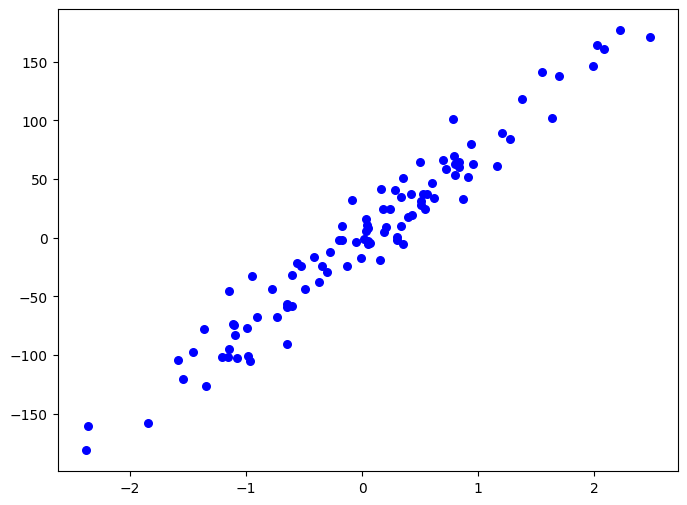

In [13]:
# plot data on graph
fig = plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], y, color="b", s=30)
plt.show()

In [14]:
def mse(y_test, predictions):
    return np.mean((y_test - predictions) ** 2)


def plot_graph(X, X_train, y_train, X_test, y_test, y_pred_line):
    cmap = plt.get_cmap("viridis")
    fig = plt.figure(figsize=(8, 6))
    m1 = plt.scatter(X_train, y_train, color=cmap(0, 9), s=10)
    m2 = plt.scatter(X_test, y_test, color=cmap(0, 5), s=10)
    plt.plot(X, y_pred_line, color="black", linewidth=2, label="Prediction")
    plt.show()

Initialial weights [0.] and bias 0
Final weights [47.78107018] and bias 0.399492078958752
LR: 0.001, MSE: 783.8155465125494


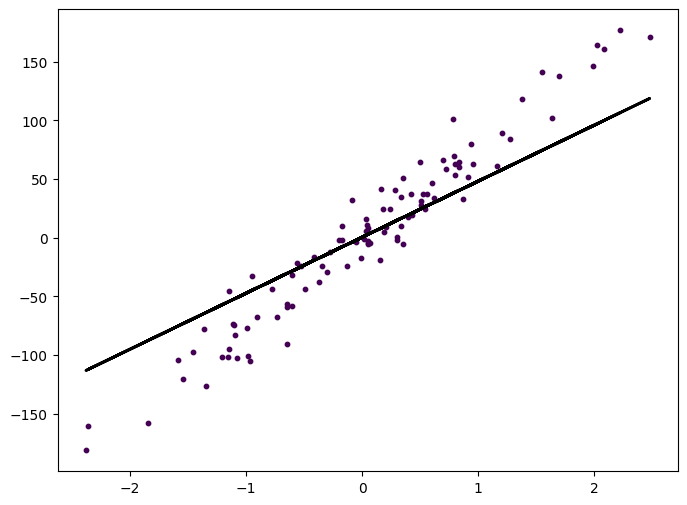

In [15]:
# Init Linear Regression and train the data using fit method
reg = LinearRegression()
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

err = mse(y_test, predictions)
print(f"LR: {reg.lr}, MSE: {err}")

y_pred_line = reg.predict(X)

plot_graph(X, X_train, y_train, X_test, y_test, y_pred_line)

In above digram regression line is not properly fit to data sets with default iterations 1000 and learning rate 0.001.

With same iterations if we want to the line properly we should increase the learning rate may be to 0.01.


Initialial weights [0.] and bias 0
Final weights [75.05642756] and bias -0.14185705476881272
LR: 0.01, MSE: 305.7719958301902


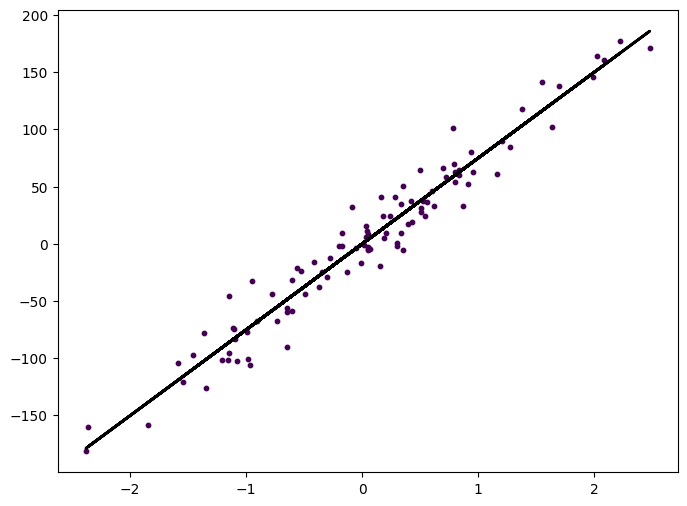

In [16]:
# Init Linear Regression and train the data using fit method
reg = LinearRegression(lr=0.01)
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

err = mse(y_test, predictions)
print(f"LR: {reg.lr}, MSE: {err}")

y_pred_line = reg.predict(X)

plot_graph(X, X_train, y_train, X_test, y_test, y_pred_line)

Now regression line looks proper fit to dataset it means with 0.01 LR and 1000 iterations our model trained and reduced loss MSE 305.7719958301902 while earlier loss was 783.8155465125494